# 15. Particles, Agents, and Flocking

Two hundred dots follow three polite rules and no leader, and a murmuration happens. Today we write the course's first class, teach it to flock the way starlings do, and photograph the whole flight in a single long exposure.

## Today's destination

The complete flight paths of two hundred simulated birds, four hundred fifty time steps of them, drawn into one frame. No path was designed; each bird knew only its nearest neighbors and three small urges, and the wreath you see is what those urges add up to. By the end of today you can generate this, film the flock in motion as a GIF, and dial its society between clumping, flocking, and gas.

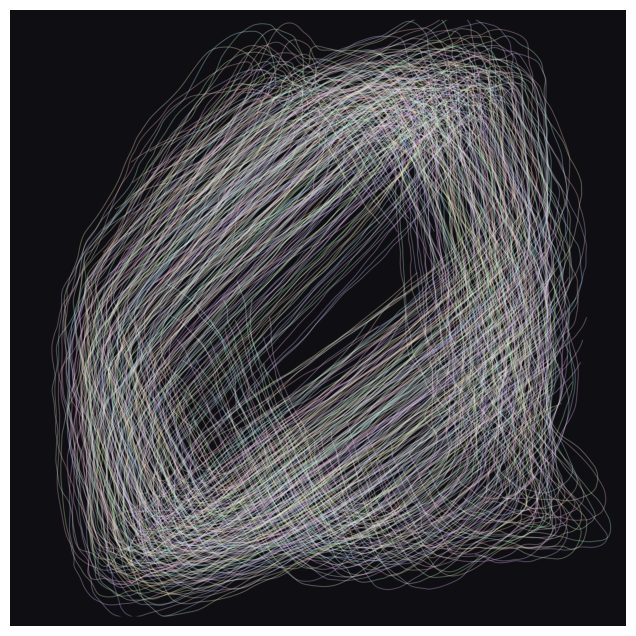

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch15_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: art that moves, art that flocks

Sculpture learned to move in the twentieth century. **Alexander Calder** began exhibiting motor-driven and then air-driven constructions in the early 1930s; **Marcel Duchamp** suggested the name *mobile*, a French pun meaning both "moving" and "motive". A Calder mobile is not a shape but a *system of balances*: the artist fixes rods, weights and hinges, then hands the composition over to the air in the room. Where Calder's systems are serene, **Jean Tinguely** built them manic: his *Homage to New York* (1960), a machine whose only purpose was to destroy itself, did so, partly, before an audience in the sculpture garden of the Museum of Modern Art. And painting learned to move without moving at all: the Op Art of **Bridget Riley** (*Movement in Squares*, 1961; *Current*, 1964) makes a perfectly static canvas shimmer through the physiology of your own retina. Motion, these artists discovered, can be *delegated*: to the wind, to a motor, to the viewer's nervous system.

Today we delegate it to a simulation, and to a very particular kind of simulation. In 1986 the computer graphics researcher **Craig Reynolds** wanted flocks of birds for film effects, and realized that animating each bird by hand, or steering the whole flock from above like a choreographer, both miss what a flock *is*. His **boids** (from "bird-oid objects"), published at SIGGRAPH in 1987, follow three local rules: keep your distance, match your neighbors' heading, stay with the group. Nothing in the code says "form a swirling cloud that splits around obstacles and reunites", yet that is what the boids do. They made their film debut the same year in the animated short *Stanley and Stella in: Breaking the Ice*, their descendants flew as the bat swarms of *Batman Returns* (1992), and in 1998 Reynolds received a scientific and technical Academy Award for this line of work. The paper remains one of the most cited in computer graphics, and one of the most quietly philosophical: it shows that *behavior* can be composed the way form can.

Contemporary art has taken the swarm to room scale. The London studio **Random International** built *Rain Room* (2012), a downpour that parts around each visitor: a ceiling grid of valves and tracking cameras enforcing a single rule, never to rain on a person. The Tokyo collective **teamLab** (founded 2001) fills museums with projected crowds of birds, petals and people that react to the audience like shoals of fish. In both, as with Calder, the artist authors the rules and the audience completes the work.

This is also the third of this book's lessons in **emergence** (Emergenz), and the ladder is worth seeing whole. Chapter 9 gave us cells on a grid, chapter 10 chemicals in a continuous field, and today gives us **agents**: entities with a position of their own, a velocity of their own, and a small private will. Grid, field, agents: three substrates, one lesson. Order does not need a conductor. (And the ladder keeps climbing: in the next two chapters, agents will freeze into frost, and agents will be wired to a field.)

## The physics of a dot

An agent's **state** is two vectors: where it is, and where it is going.

$$\vec p = \begin{pmatrix} x \\ y \end{pmatrix} \qquad \vec v = \begin{pmatrix} v_x \\ v_y \end{pmatrix}$$

Time advances in small steps, and each step does two things: forces bend the velocity, and the velocity moves the position.

$$\vec v_{t+1} = \vec v_t + \vec f_t \qquad\qquad \vec p_{t+1} = \vec p_t + \vec v_{t+1}$$

This recipe is the **Euler step**, after Leonhard Euler (1707–1783), and it is the humblest member of a large family of *integration* methods; physicists use fancier ones when precision matters, game and graphics people use this one because it is fast and looks right. (We fold the time step $\Delta t$ into the units and set it to 1. And strictly, updating the position with the *freshly bent* velocity makes this the semi-implicit Euler step, the variant that stays stable; the textbook version moves with the old velocity and slowly gains energy it should not have.) Watch it produce the oldest curve in physics from nothing but repeated addition:

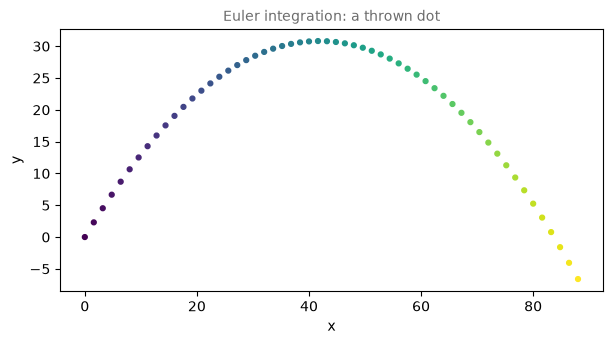

In [2]:
# one dot obeying Euler: a sideways throw plus a constant downward pull
import numpy as np

position = np.array([0.0, 0.0])
velocity = np.array([1.6, 2.4])
gravity = np.array([0.0, -0.09])
path = [position.copy()]
for step in range(55):
    velocity = velocity + gravity          # the force bends the velocity
    position = position + velocity         # the velocity moves the position
    path.append(position.copy())
path = np.array(path)

plt.figure(figsize=(7, 3.4))
plt.scatter(path[:, 0], path[:, 1], s=12, c=range(len(path)), cmap="viridis")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler integration: a thrown dot", fontsize=10, color="#6B6B6B")
plt.show()

A parabola, two additions at a time. Every particle system in every game and film works exactly like this loop; the art is in choosing the forces. Ours will come from the neighbors.

## Ten minutes on classes, the course's first

For thirteen chapters we have kept state in variables and behavior in functions, and passed the one to the other by hand. That works, but an *agent* wants its luggage and its habits in one place: this bird's position, this bird's velocity, and the ability to take a step, all traveling together under one name.

Python's tool for this is the **class** (Klasse). A class is a blueprint that bundles variables with the functions allowed to act on them. Some vocabulary, worth exactly one reading:

- an **object** (or *instance*) is one concrete thing built from the blueprint: one boid;
- its **attributes** are the variables it carries (`position`, `velocity`);
- its **methods** are the functions that live inside it (`step`);
- `self` means "this particular object": inside a method, `self.position` is *my* position;
- `__init__` is the method that runs once at birth and sets the attributes up.

You have secretly used objects all semester. Every `fig` and `ax` from matplotlib is an object (`ax.scatter(...)` is a method call on it), and so is every `rng` from chapter 2. Today you finally build your own:

In [3]:
# the course's first class: a Boid is a bundle of state plus behavior
class Boid:
    def __init__(self, x, y, vx, vy):
        self.position = np.array([x, y], dtype=float)
        self.velocity = np.array([vx, vy], dtype=float)

    def step(self):
        self.position = self.position + self.velocity

luna = Boid(0, 0, 1.0, 0.5)
stella = Boid(5, 0, -0.5, 1.0)
for tick in range(3):
    luna.step()
    stella.step()
print("luna is at", luna.position)
print("stella is at", stella.position)

luna is at [3.  1.5]
stella is at [3.5 3. ]


Read it slowly once. `Boid(0, 0, 1.0, 0.5)` calls `__init__` and hands back a newborn object; `luna.step()` runs `step` with `self` set to luna, so only luna moves by luna's velocity. Two boids, two private states, one shared blueprint. A class is not a locked box, either: `luna.velocity = ...` from outside is perfectly legal, and we will use that freedom in the exercises.

**Try it.** Give the class a third method, `def wobble(self):`, that adds a small random number (from a seeded `rng`, chapter 2 style) to `self.velocity`, and call it between steps. The syntax is the only lesson here; make the boid yours.

One honest engineering note before we scale up. Two hundred boids each checking all others is $200 \times 199 = 39{,}800$ distance measurements *per frame*, and we want hundreds of frames. Looping over Python objects for that is leisurely; numpy arrays do all pairs at once. So we will keep the class idea, but store the *whole flock* inside one object: two arrays of shape `(n, 2)`, one for all positions, one for all velocities. One blueprint, one object, two hundred birds.

## Three rules, no conductor

Reynolds' insight was that flocking needs only three **steering forces**, each computed by every boid from its own neighborhood, with nobody seeing the whole picture.

**1. Separation** (don't crowd me): steer away from each boid that is too close, more urgently the closer it is.

$$\vec f^{\,\text{sep}}_i = \sum_{j \,\in\, \text{close}(i)} \frac{\vec p_i - \vec p_j}{\lVert \vec p_i - \vec p_j \rVert^2}$$

**2. Alignment** (fly as we fly): steer toward the average velocity of the neighbors.

$$\vec f^{\,\text{ali}}_i = \frac{1}{|N_i|} \sum_{j \,\in\, N_i} \vec v_j \;-\; \vec v_i$$

**3. Cohesion** (stay with us): steer toward the neighbors' center of gravity.

$$\vec f^{\,\text{coh}}_i = \frac{1}{|N_i|} \sum_{j \,\in\, N_i} \vec p_j \;-\; \vec p_i$$

Who counts as a neighbor? Anybody within a fixed **radius**. Separation uses a short radius, alignment and cohesion a longer one: personal space is smaller than social space. That is the entire theory. First we need every distance between every pair, and chapter 12's broadcasting trick (`pixels[:, None, :] - points[None, :, :]`, from the Lloyd cell) does all pairs in one line:

In [4]:
# every boid measures every other: broadcasting does all pairs at once
def pairwise(pos):
    offsets = pos[None, :, :] - pos[:, None, :]   # offsets[i, j]: from i to j
    distances = np.linalg.norm(offsets, axis=2)   # ch12's norm, now for all pairs
    np.fill_diagonal(distances, np.inf)           # nobody is their own neighbor
    return offsets, distances

rng = np.random.default_rng(3)
five = rng.uniform(0, 10, (5, 2))
offsets, distances = pairwise(five)
print("5 positions ->", offsets.shape, "offsets,", distances.shape, "distances")
print(np.round(distances, 1))

5 positions -> (5, 5, 2) offsets, (5, 5) distances
[[inf 7.9 2.  4.  6.6]
 [7.9 inf 7.2 5.3 4.7]
 [2.  7.2 inf 4.7 7.2]
 [4.  5.3 4.7 inf 2.6]
 [6.6 4.7 7.2 2.6 inf]]


The distance table is symmetric, and the diagonal is set to infinity so that a boid never reacts to itself (infinity is farther than any radius). Now the three urges, each a few lines:

In [5]:
# the three rules as code: each returns one steering force per boid
def separation(offsets, distances, near):
    # away from each too-close boid, harder the closer it is
    push = -offsets / distances[:, :, None]**2
    return np.where(near[:, :, None], push, 0).sum(axis=1)

def alignment(vel, near):
    # toward the average velocity of the neighbors
    count = np.maximum(near.sum(axis=1, keepdims=True), 1)
    mean_vel = (near[:, :, None] * vel[None, :, :]).sum(axis=1) / count
    return np.where(near.sum(axis=1, keepdims=True) > 0, mean_vel - vel, 0)

def cohesion(pos, near):
    # toward the neighbors' center of gravity
    count = np.maximum(near.sum(axis=1, keepdims=True), 1)
    center = (near[:, :, None] * pos[None, :, :]).sum(axis=1) / count
    return np.where(near.sum(axis=1, keepdims=True) > 0, center - pos, 0)

Each function takes `near`, a boolean table saying who counts for whom (`distances < radius`), and returns one force vector per boid. The `[..., None]` is chapter 13's axis-adding trick, here letting a yes/no table meet a table of 2D vectors; `np.where` (chapter 8) then keeps only the neighbors' contributions. Two small newcomers ride along: `keepdims=True` makes a sum keep its summed-away axis as size 1 (the same shape trick as `[:, None]`, spelled as an argument), and `np.maximum(..., 1)` is the elementwise cousin of `max`, guarding the divisions for a boid with zero neighbors. Such a boid, with nobody in range, feels nothing. Let us *see* the three urges before trusting them, on a frozen random crowd:

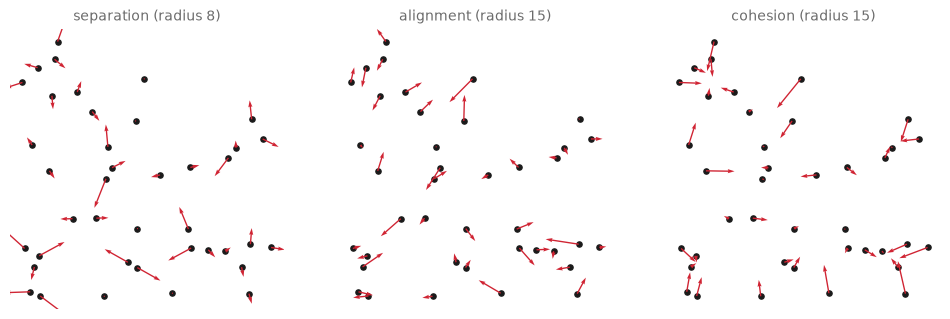

In [6]:
# the three urges, drawn: red arrows are the forces on a frozen crowd
rng = np.random.default_rng(11)
crowd = rng.uniform(20, 80, (40, 2))
crowd_vel = rng.normal(0, 0.5, (40, 2))
offsets, distances = pairwise(crowd)
forces = {
    "separation (radius 8)": separation(offsets, distances, distances < 8),
    "alignment (radius 15)": alignment(crowd_vel, distances < 15),
    "cohesion (radius 15)": cohesion(crowd, distances < 15),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (name, force) in zip(axes, forces.items()):
    ax.scatter(crowd[:, 0], crowd[:, 1], s=14, color="#1A1A1A")
    ax.quiver(crowd[:, 0], crowd[:, 1], force[:, 0], force[:, 1],
              color="#D02433", width=0.005)
    ax.set_title(name, fontsize=10, color="#6B6B6B")
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

Separation only wakes up where dots nearly touch, and pushes the pair apart. Alignment tugs every velocity toward the local consensus. Cohesion points every loner at its nearest cluster. No arrow knows anything beyond its own radius.

**Try it.** Change the separation radius from 8 to 20 and rerun: suddenly everyone is "too close" and the crowd wants to explode evenly. The radii are social policy.

## Speed limits and walls

Two housekeeping forces keep the simulation civilized. First, raw rule-following can accelerate a boid without bound or stall it to a standstill, so after adding the forces we **clamp the speed**: keep the velocity's direction, but clip its length into a band.

$$\vec v \;\leftarrow\; \frac{\vec v}{\lVert \vec v \rVert} \cdot \operatorname{clip}\!\left(\lVert \vec v \rVert,\; v_{\min},\; v_{\max}\right)$$

A minimum speed is the nice trick here: real birds cannot hover, and a flock that can never stop keeps its drawings alive. Second, our canvas has edges; rather than teleporting boids across (which would slash straight lines through the long exposure), we let the walls push back gently, like a soft cushion of air starting a few units before the edge.

In [7]:
# housekeeping forces: clamp the speed into a band, cushion the walls
def limit_speed(vel, slowest, fastest):
    speed = np.maximum(np.linalg.norm(vel, axis=1, keepdims=True), 1e-9)
    return vel / speed * np.clip(speed, slowest, fastest)

def keep_inside(pos, size, margin=10, strength=0.08):
    force = np.zeros_like(pos)
    force = force + np.where(pos < margin, strength, 0.0)
    force = force - np.where(pos > size - margin, strength, 0.0)
    return force

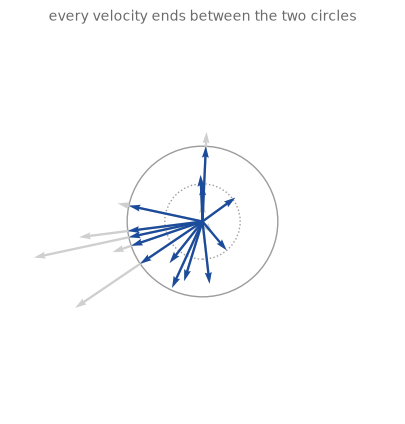

In [8]:
# speed limits, drawn: gray raw velocities, blue clamped ones, one band
# (angles/scale_units "xy": quiver arrows drawn in data units, at true length)
raw = np.random.default_rng(7).normal(0, 0.8, (14, 2))
clamped = limit_speed(raw, slowest=0.45, fastest=0.9)

fig, ax = plt.subplots(figsize=(5, 5))
for radius, style in [(0.45, ":"), (0.9, "-")]:
    ax.add_patch(plt.Circle((0, 0), radius, fill=False, linestyle=style,
                            color="#9C9C9C"))
ax.quiver(np.zeros(14), np.zeros(14), raw[:, 0], raw[:, 1], color="#CFCFCF",
          angles="xy", scale_units="xy", scale=1, width=0.006)
ax.quiver(np.zeros(14), np.zeros(14), clamped[:, 0], clamped[:, 1],
          color="#1B4B9B", angles="xy", scale_units="xy", scale=1, width=0.006)
ax.set_title("every velocity ends between the two circles",
             fontsize=10, color="#6B6B6B")
ax.set_xlim(-2.3, 2.3)
ax.set_ylim(-2.3, 2.3)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## The Flock

Now the second class of the day, and the real one: the whole flock as one object. Its attributes are the two state arrays plus the settings of its society; its one method is the Euler step, with the three rules (weighted by a `weights` triple: separation, alignment, cohesion) providing the force.

In [9]:
# the whole flock in one object: arrays as state, one Euler step as behavior
class Flock:
    def __init__(self, n_boids=200, size=100, seed=14, speed=(0.45, 0.9),
                 weights=(0.25, 0.1, 0.02), radii=(4.0, 10.0)):
        rng = np.random.default_rng(seed)
        self.size = size
        self.speed = speed
        self.weights = weights                   # separation, alignment, cohesion
        self.radii = radii                       # personal space, social space
        self.pos = rng.uniform(0, size, (n_boids, 2))
        angle = rng.uniform(0, 2 * np.pi, n_boids)
        self.vel = 0.7 * np.stack([np.cos(angle), np.sin(angle)], axis=1)

    def step(self):
        offsets, distances = pairwise(self.pos)
        w_sep, w_ali, w_coh = self.weights
        force = (w_sep * separation(offsets, distances, distances < self.radii[0])
                 + w_ali * alignment(self.vel, distances < self.radii[1])
                 + w_coh * cohesion(self.pos, distances < self.radii[1])
                 + keep_inside(self.pos, self.size))
        # the * spreads the (slowest, fastest) pair into two arguments
        self.vel = limit_speed(self.vel + force, *self.speed)
        self.pos = self.pos + self.vel

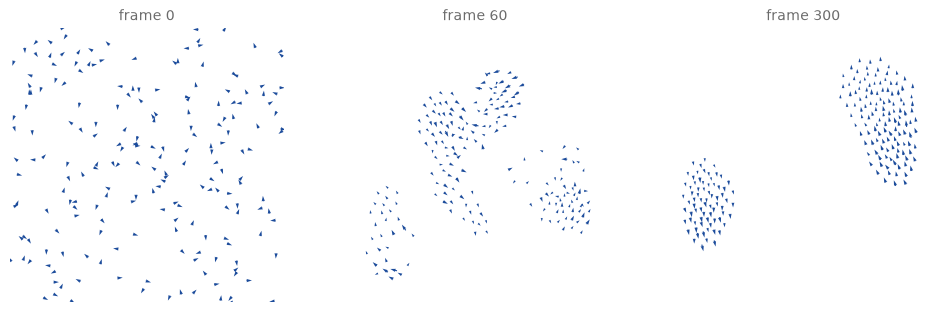

In [10]:
# three moments of one flock: random start, first alliances, murmuration
flock = Flock(seed=14)
moments = {0: (flock.pos.copy(), flock.vel.copy())}
for frame in range(1, 301):
    flock.step()
    if frame in (60, 300):
        moments[frame] = (flock.pos.copy(), flock.vel.copy())

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (frame, (pos, vel)) in zip(axes, moments.items()):
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1], color="#1B4B9B",
              width=0.004, scale=35)
    ax.set_title(f"frame {frame}", fontsize=10, color="#6B6B6B")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

At frame 0 the arrows point everywhere: pure chapter-2 randomness. By frame 60, local alliances: little squads agree on headings. By frame 300 the squads have merged into a few coherent streams sweeping the canvas. Nothing chose that structure; it condensed out of 39,800 distance checks per frame. This is the moment to say what **emergence** (chapter 9's word, now in its third costume) means precisely: the flock has properties (a shape, a direction, a mood) that none of its members has, and that nobody wrote down.

**Try it.** Rebuild the flock with `weights=(0.25, 0.0, 0.02)` (no alignment) and rerun the cell: squads never form, only polite avoidance. Alignment, the blandest-sounding rule, turns out to be the one that makes a crowd into a *collective*.

## Watching it happen

A flock is a time-based artwork, so let us film it. Chapter 9's GIF recipe works unchanged; the one new idea is a canvas with memory. Instead of drawing each frame from scratch, we let the previous frame *fade* by multiplying it with 0.85 before stamping the new positions on top: cheap motion blur, and each boid trails a comet tail exactly as long as its recent past. (`np.kron`, our pixel enlarger from chapters 9 and 13, scales the film up.)

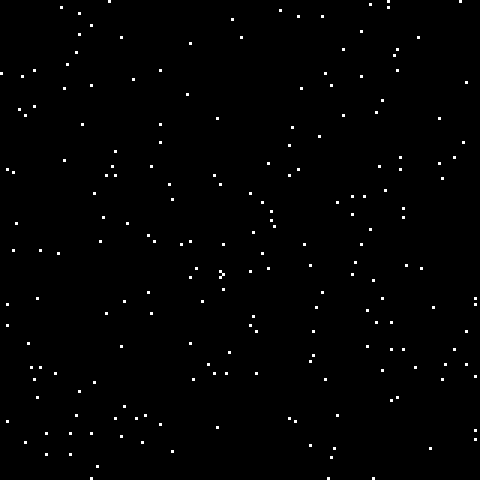

In [11]:
# film the flock finding itself: fresh dots on a slowly fading canvas
import imageio.v2 as imageio
from IPython.display import Image as GifImage

flock = Flock(seed=14)
resolution = 160
canvas = np.zeros((resolution, resolution))
gif_frames = []
for frame in range(300):
    flock.step()
    ink = np.zeros((resolution, resolution))
    cell = np.clip((flock.pos / flock.size * resolution).astype(int),
                   0, resolution - 1)
    ink[cell[:, 1], cell[:, 0]] = 1.0
    canvas = canvas * 0.85 + ink             # old light fades, new light lands
    bright = np.round(np.clip(canvas, 0, 1) * 4) / 4    # 5 grays: smaller file
    gif_frames.append(np.kron(bright * 255, np.ones((3, 3))).astype(np.uint8))

gif_path = "../assets/outputs/ch15_flock.gif"
imageio.mimsave(gif_path, gif_frames, fps=25, loop=0)
GifImage(filename=gif_path)

**Try it.** Change the fading factor 0.85 to 0.6 (short, nervous tails) or 0.97 (long ghostly ribbons) and re-run. You are choosing the shutter speed of an imaginary camera.

## The long exposure

Which brings us to the artwork. In the 1880s the physiologist **Étienne-Jules Marey** photographed birds, runners and fencers with his *chronophotographic* cameras, layering many instants onto one plate; motion itself, not the mover, became the picture. His plates fascinated painters: Marcel Duchamp said his *Nude Descending a Staircase, No. 2* (1912) owed them a debt, and the Futurists mined them for their "lines of force". We now do exactly what Marey did, with a shutter that stays open for the whole simulation: record every position of every boid, then draw each bird's entire flight as one polyline. Two functions: a simulation that returns the full history (with a `warmup` so the shutter opens only after the flock has found itself), and a renderer in the spirit of chapter 8's `draw_trails`, with one refinement: each boid gets its own faint hue, so the streams shimmer like oil on water. (One piece of new syntax in `simulate`: `**flock_settings` scoops up whatever keyword arguments you pass and hands them to `Flock` unchanged, so every dial of the society stays reachable.)

In [12]:
# part 1: run the society and keep every position of every boid
def simulate(n_frames=450, warmup=150, **flock_settings):
    flock = Flock(**flock_settings)
    for frame in range(warmup):                # let the flock find itself
        flock.step()
    history = [flock.pos.copy()]
    for frame in range(n_frames):
        flock.step()
        history.append(flock.pos.copy())
    return np.array(history)                   # (n_frames + 1, n_boids, 2)

history = simulate()
print("recorded:", history.shape, "(frames, boids, xy)")

recorded: (451, 200, 2) (frames, boids, xy)


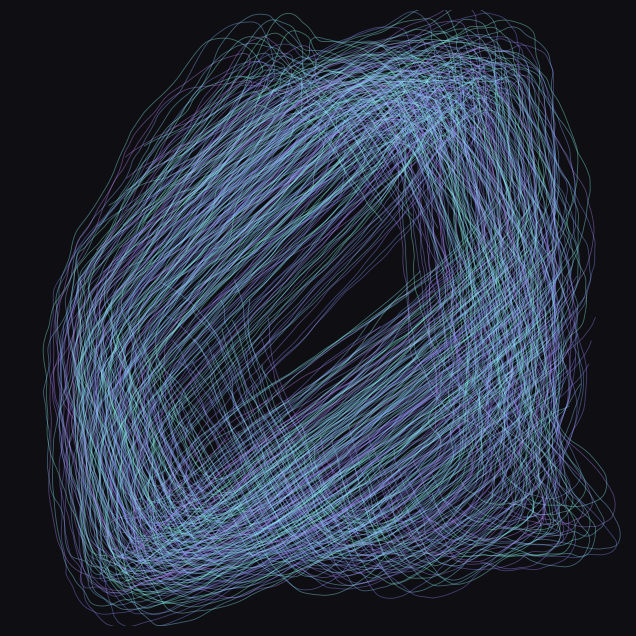

In [13]:
# part 2: the long exposure -- every flight path as one faintly hued line
from matplotlib.collections import LineCollection
from matplotlib.colors import hsv_to_rgb   # ch2/ch5's colorsys trick, for whole arrays

def long_exposure(history, hue=None, hue_span=1.0, saturation=0.22, value=1.0,
                  background="#0E0E13", linewidth=0.65, alpha=0.38,
                  size=100, seed=14, figsize=8):
    n_boids = history.shape[1]
    rng = np.random.default_rng(seed)
    if hue is None:
        hues = rng.random(n_boids)             # every hue, at low saturation
    else:
        hues = (hue + hue_span * (rng.random(n_boids) - 0.5)) % 1.0
    hsv = np.stack([hues, np.full(n_boids, saturation),
                    np.full(n_boids, value)], axis=1)
    trails = history.transpose(1, 0, 2)        # swap the first two axes: one (frames, 2) path per boid
    fig, ax = plt.subplots(figsize=(figsize, figsize), facecolor=background)
    ax.add_collection(LineCollection(trails, colors=hsv_to_rgb(hsv),
                                     linewidths=linewidth, alpha=alpha))
    ax.set_facecolor(background)
    ax.set_xlim(-2, size + 2)
    ax.set_ylim(-2, size + 2)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

# the flight we just recorded, exposed in a cold light
exposure = long_exposure(history, hue=0.6, hue_span=0.3, saturation=0.45)

In [14]:
# part 3: the finished generator -- one call from society to artwork
import sys
sys.path.append("..")
from agap.helpers import PAPER, save_artwork

def flock_trails(n_boids=200, n_frames=450, warmup=150,
                 weights=(0.25, 0.1, 0.02), radii=(4.0, 10.0),
                 speed=(0.45, 0.9), seed=14, hue=None, hue_span=1.0,
                 saturation=0.22, value=1.0, background="#0E0E13",
                 linewidth=0.65, alpha=0.38, figsize=8):
    history = simulate(n_frames=n_frames, warmup=warmup, n_boids=n_boids,
                       seed=seed, speed=speed, weights=weights, radii=radii)
    return long_exposure(history, hue=hue, hue_span=hue_span,
                         saturation=saturation, value=value,
                         background=background, linewidth=linewidth,
                         alpha=alpha, seed=seed, figsize=figsize)

## Playground: three societies

The `weights` triple is a constitution: it decides what kind of society the same two hundred boids will be. Three settings, three temperaments. (As always, every seed below is an invitation: change it and the society reruns its history differently.)

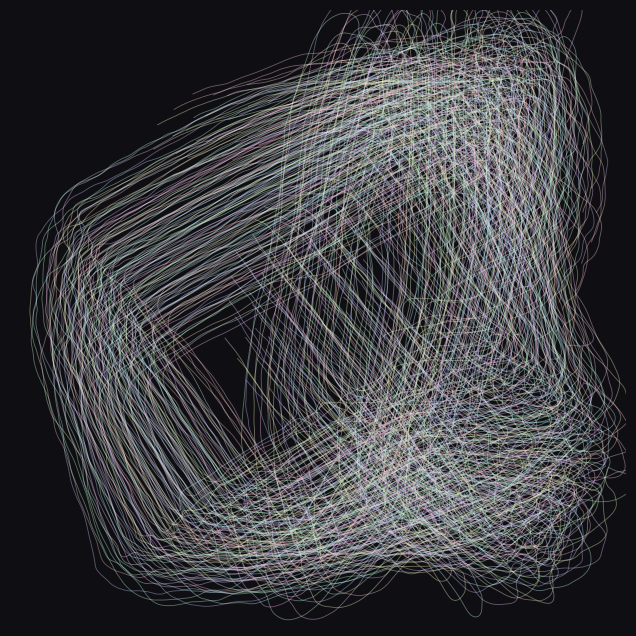

In [15]:
# balanced weights: the murmuration
art_1 = flock_trails(seed=5)

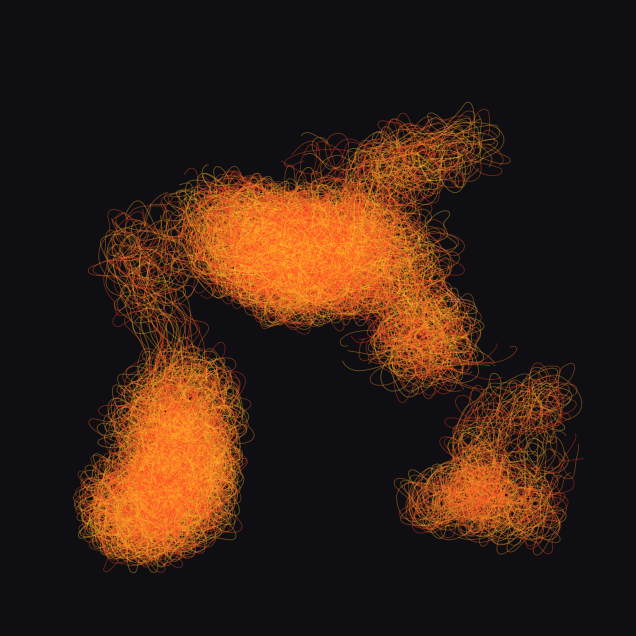

In [16]:
# cohesion-heavy: the flock curdles into knots, drawn here in ember light
art_2 = flock_trails(weights=(0.15, 0.02, 0.06), n_frames=600, warmup=120,
                     hue=0.07, hue_span=0.12, saturation=0.85)

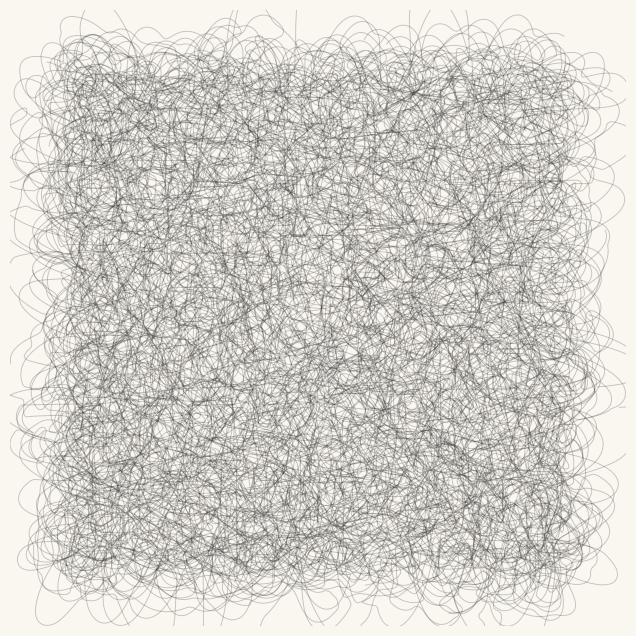

In [17]:
# separation-heavy: a gas of loners, drawn as ink on paper
art_3 = flock_trails(weights=(0.9, 0.0, 0.002), value=0.15, saturation=0.1,
                     background=PAPER, alpha=0.25)

**Look and compare.** Three temperaments from one blueprint: the murmuration's braided streams, the ember knots circling their own gravity, the gas filling the page with an even, all-over scribble that has no center at all (a texture the Abstract Expressionists reached by very different means). Which of the three feels most *alive* to you, and which single weight is responsible? Notice also what the colors do: the same trails read as biology in warm hues on black and as a drawing in ink on paper. Chapter 5's lesson keeps collecting rent.

## Export your artwork

Pick a constitution, a palette mood, a seed. Two hundred birds will fly it for you. Replace `yourname` and run.

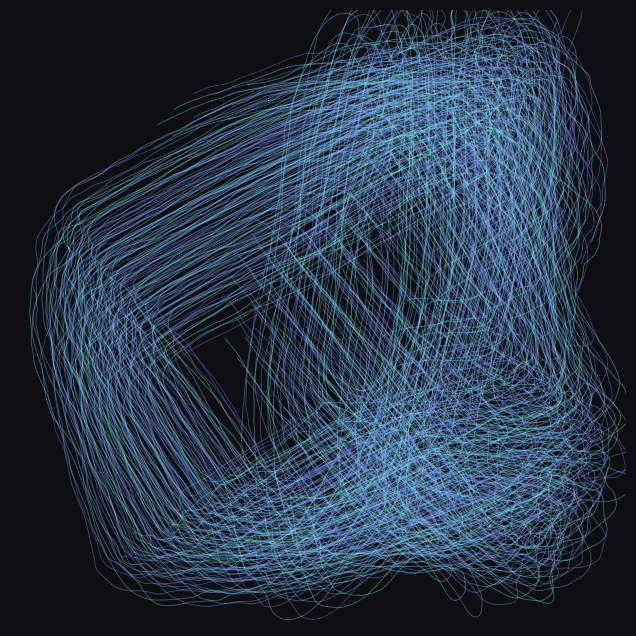

saved: assets/outputs/ch15_yourname.png


In [18]:
# save YOUR artwork: tune the society, then replace 'yourname'
my_flock = flock_trails(seed=5, hue=0.58, hue_span=0.2, saturation=0.5)
saved_path = save_artwork(my_flock, "yourname", chapter=15)

## Exercises

**(a) Parameter exploration: a predator.** Add one hawk. A predator is just one more position that moves toward the flock's center of gravity each frame (`flock.pos.mean(axis=0)`), a little slower than the boids' top speed; the boids add one more force, away from the predator, for everyone within a fear radius (reuse the separation idea with a single opponent). Explore the fear weight: at a whisper the flock dents and heals around the hawk; at a shout it shatters. Somewhere in between are the pulsing, splitting shapes that starling murmurations show when a real falcon attacks; the long exposure of a good chase is a dramatic artwork.

**(b) Code modification: wind.** Chapter 8 gave us fields of coherent noise; a flock deserves weather. Build an angle grid from opensimplex noise (exactly as in chapter 8's flow fields), and each frame add a small wind force to `flock.vel` before stepping: each boid feels the wind of the grid cell it currently flies through. A class is an open box: you can reach into its attributes from outside, no changes to `Flock` needed.

<details><summary>Solution</summary>

```python
import opensimplex

opensimplex.seed(8)
resolution = 100
coords = np.linspace(0, 2.5, resolution)
wind_angles = opensimplex.noise2array(coords, coords) * np.pi   # one octave

def simulate_windy(n_frames=450, warmup=150, wind=0.06, **flock_settings):
    flock = Flock(**flock_settings)
    for frame in range(warmup):
        flock.step()
    history = [flock.pos.copy()]
    for frame in range(n_frames):
        cell = np.clip((flock.pos / flock.size * resolution).astype(int),
                       0, resolution - 1)
        angle = wind_angles[cell[:, 1], cell[:, 0]]
        gust = wind * np.stack([np.cos(angle), np.sin(angle)], axis=1)
        flock.vel = flock.vel + gust      # reach right into the object
        flock.step()
        history.append(flock.pos.copy())
    return np.array(history)

windy = long_exposure(simulate_windy(seed=14))
```

The wind bends every stream toward the noise field's currents: the flock now negotiates between three inner urges and one outer weather, and the drawing records the treaty. Raise `wind` to 0.15 and the weather wins.
</details>

**(c) Creative challenge: the flock paints.** Attract the boids to the dark pixels of an image. Load any picture in grayscale at a small size (chapter 12's loading recipe), blur it generously (chapter 13's blur kernel), and take the brightness *gradient* with `np.gradient`: at every pixel this points uphill toward light, so its negative points toward darkness. Add that, sampled at each boid's position, as a force. Then render the long exposure and watch two hundred birds spend six hundred frames slowly *drawing* your image: dense traffic where the picture is dark, empty sky where it is light. Tune the force weight so the image is suggested rather than traced; bring the best one to the gallery.

## Further reading

- Craig Reynolds, "Flocks, Herds, and Schools: A Distributed Behavioral Model" (SIGGRAPH 1987): the original paper, still readable; his boids page at red3d.com/cwr/boids keeps a living bibliography of everything that flocked since.
- Daniel Shiffman, *The Nature of Code*, chapters on autonomous agents (free online at natureofcode.com): the standard creative-coding treatment of steering behaviors, with many variations to steal.
- Jack Burnham, "Systems Esthetics" (*Artforum*, September 1968): the classic art-theoretical argument that the artwork of our time is the system, not the object; written the same decade the mobiles stopped being scandalous.
- Marta Braun, *Picturing Time: The Work of Etienne-Jules Marey* (1992): the standard study of chronophotography, where science's long exposures became modern art's favorite borrowed instrument.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: two hundred boids, a 150-frame warmup for the flock to find itself, then 450 frames with the shutter open. It runs automatically with *Restart & Run All*.

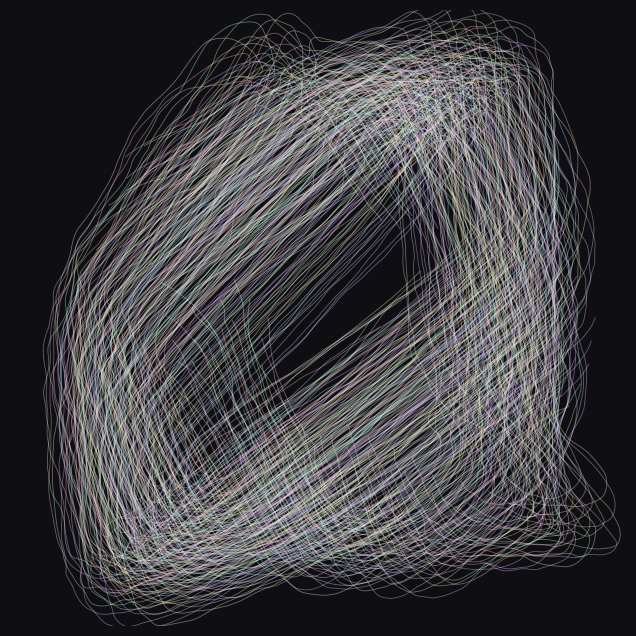

saved: assets/outputs/ch15_showpiece.png


In [19]:
# regenerate this chapter's showpiece: the murmuration long exposure
showpiece = flock_trails(seed=14)
saved_path = save_artwork(showpiece, "showpiece", chapter=15)